# Time Series Demand Forecasting

## Project Overview

This project develops a demand forecasting workflow using multiple machine learning and time-series forecasting approaches.

The first notebook evaluates:

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor
4. SARIMAX

A separate notebook extends the project using an LSTM deep learning model.

The objective is to investigate historical demand patterns, engineer useful time-based features, train multiple forecasting models, evaluate their performance, and understand the strengths and limitations of each approach.

---

# Business Objective

The objective of this project is to forecast demand using historical sales/demand information.

Accurate demand forecasting can support business activities such as:

- Inventory planning
- Stock replenishment
- Production planning
- Supply-chain planning
- Workforce planning
- Resource allocation
- Demand management

The project compares different modelling approaches to understand which methods are useful for different forecasting scenarios.

---

# Project Process Flow

```text
Business Problem
       ↓
Load Dataset
       ↓
Data Inspection
       ↓
Data Cleaning / Preparation
       ↓
Date Conversion & Sorting
       ↓
Exploratory Time-Series Analysis
       ↓
Feature Engineering
       ↓
Train/Test Preparation
       ↓
┌──────────────────────────────────────────┐
│                                          │
│        Machine Learning Models           │
│                                          │
│  Linear Regression                       │
│  Random Forest Regressor                │
│  Gradient Boosting Regressor             │
│                                          │
└──────────────────────────────────────────┘
       ↓
MAE / RMSE / R² Evaluation
       ↓
Time-Series Analysis
       ↓
Decomposition
       ↓
ADF Stationarity Test
       ↓
ACF / PACF Analysis
       ↓
Store 1 + Item 1 Selection
       ↓
SARIMAX
       ↓
365-Step Forecast
       ↓
MAE / RMSE / R² Evaluation
       ↓
Separate LSTM Notebook
       ↓
Final Model Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\tg_mu\Data Science\GitHub\Time Series Forecasting\train.csv")
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
df.shape

(913000, 4)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [5]:
df.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['date']=pd.to_datetime(df['date'])

In [8]:
df=df.sort_values('date').reset_index(drop=True)

In [9]:
df.describe()

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 12:00:00.000000256,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


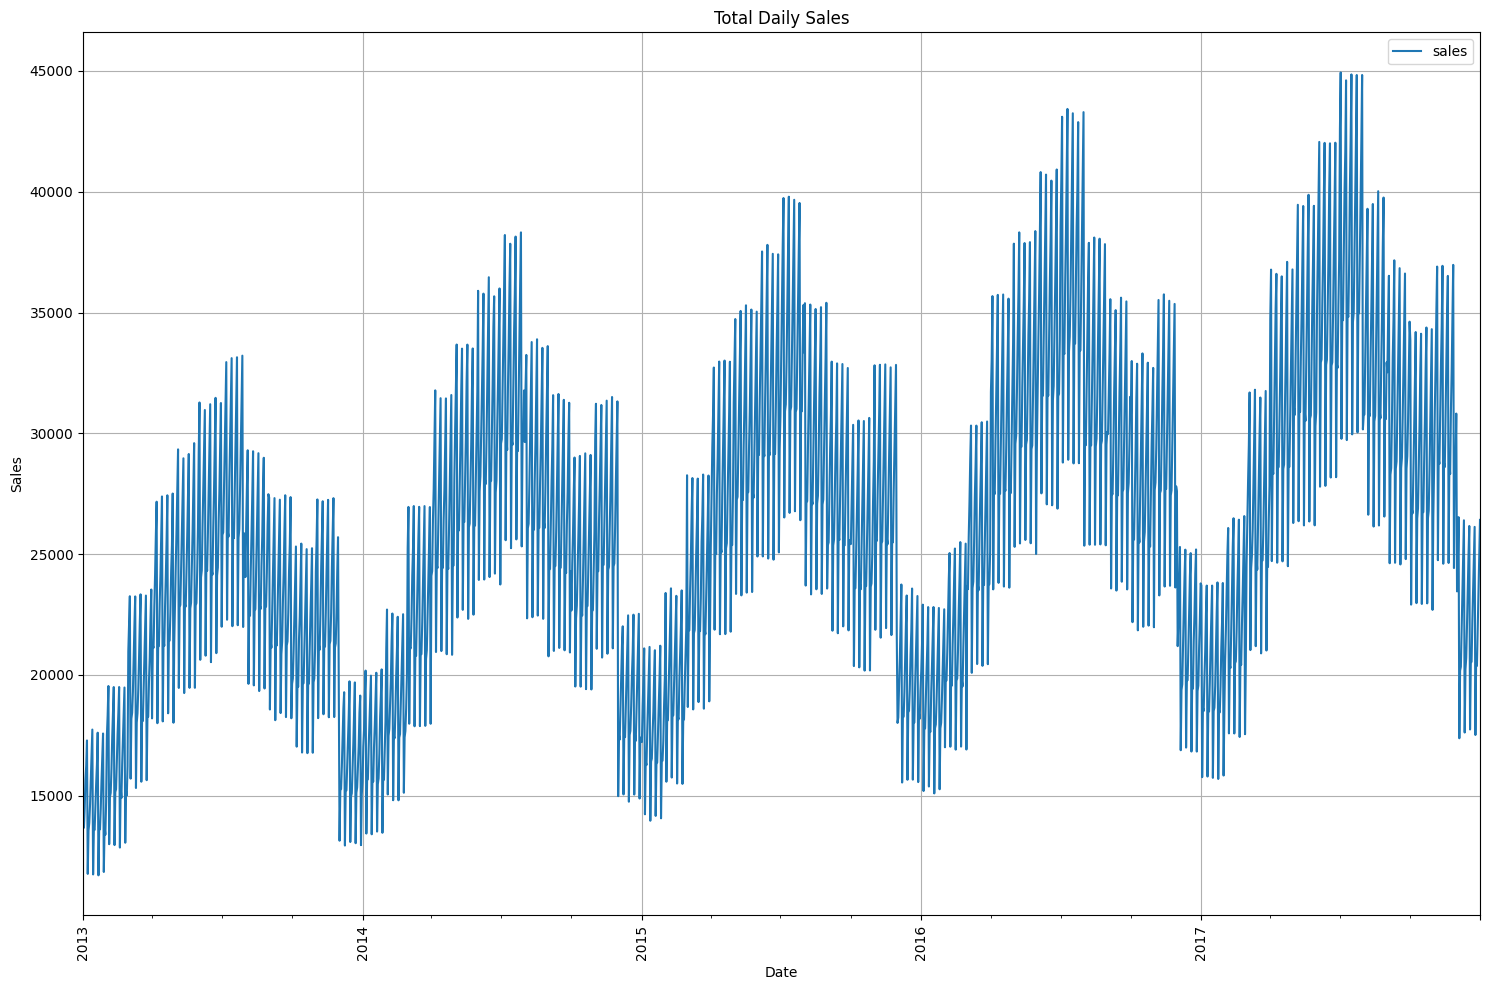

In [10]:
#Total daily sales
total_daily_sales=df.groupby('date')['sales'].sum()
total_daily_sales.plot(figsize=(15,10))
plt.title('Total Daily Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.grid()
plt.savefig('visualizations/Total Daily Sales.png')
plt.show()

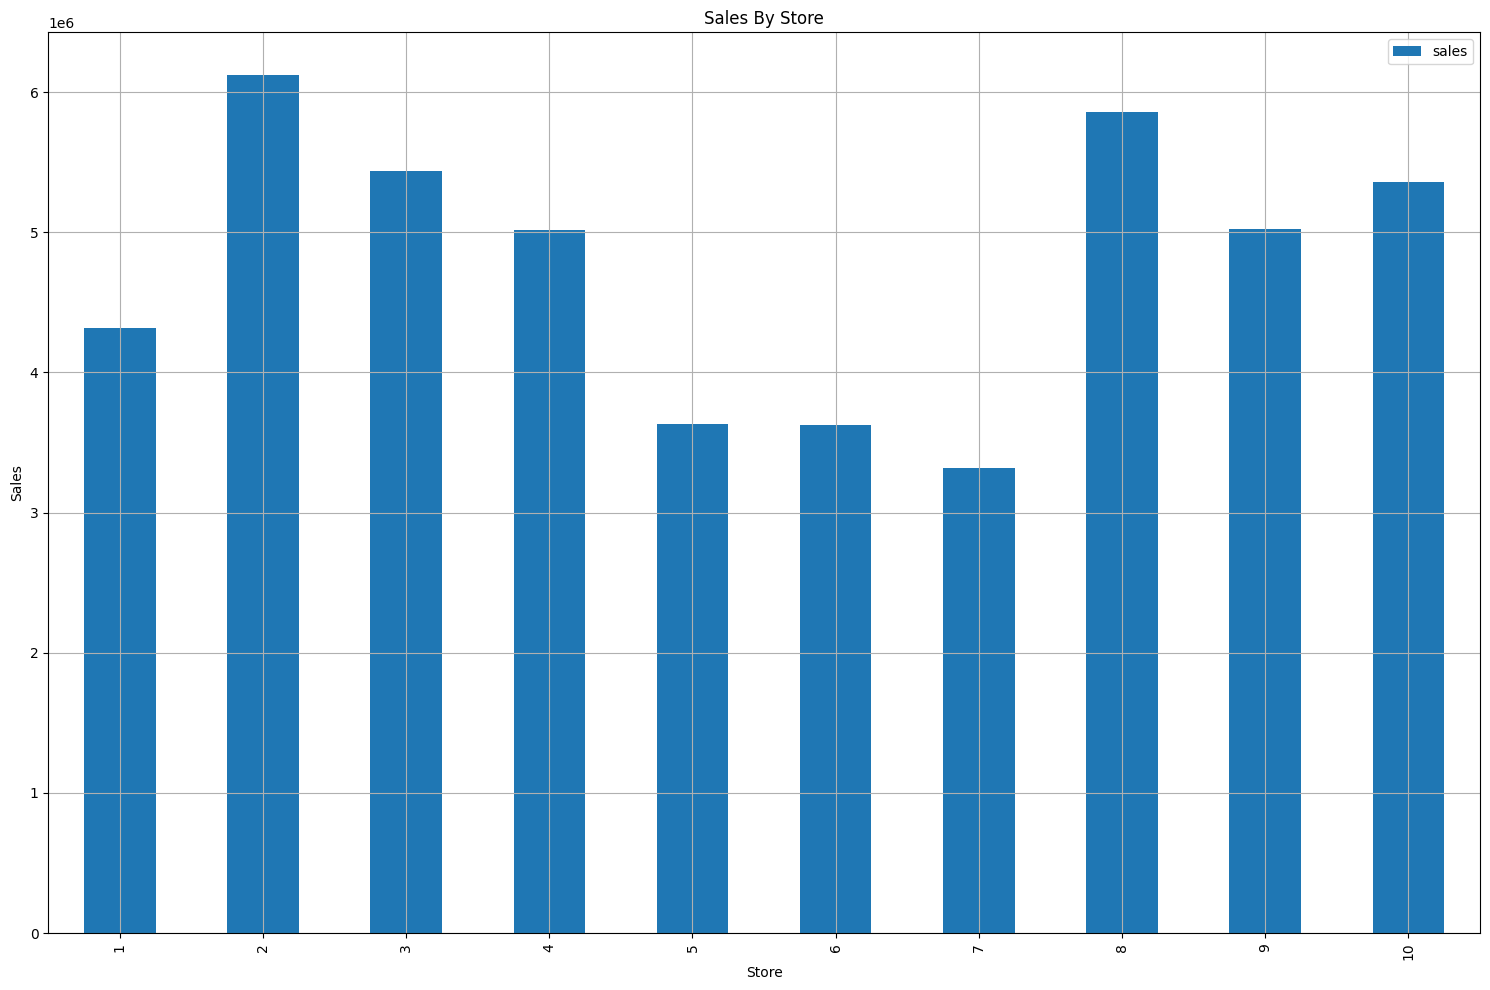

In [11]:
#Sales by store
sales_store=df.groupby('store')['sales'].sum()
sales_store.plot.bar(figsize=(15,10))
plt.title('Sales By Store')
plt.xlabel('Store')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.grid()
plt.savefig('visualizations/Sales by store.png')
plt.show()

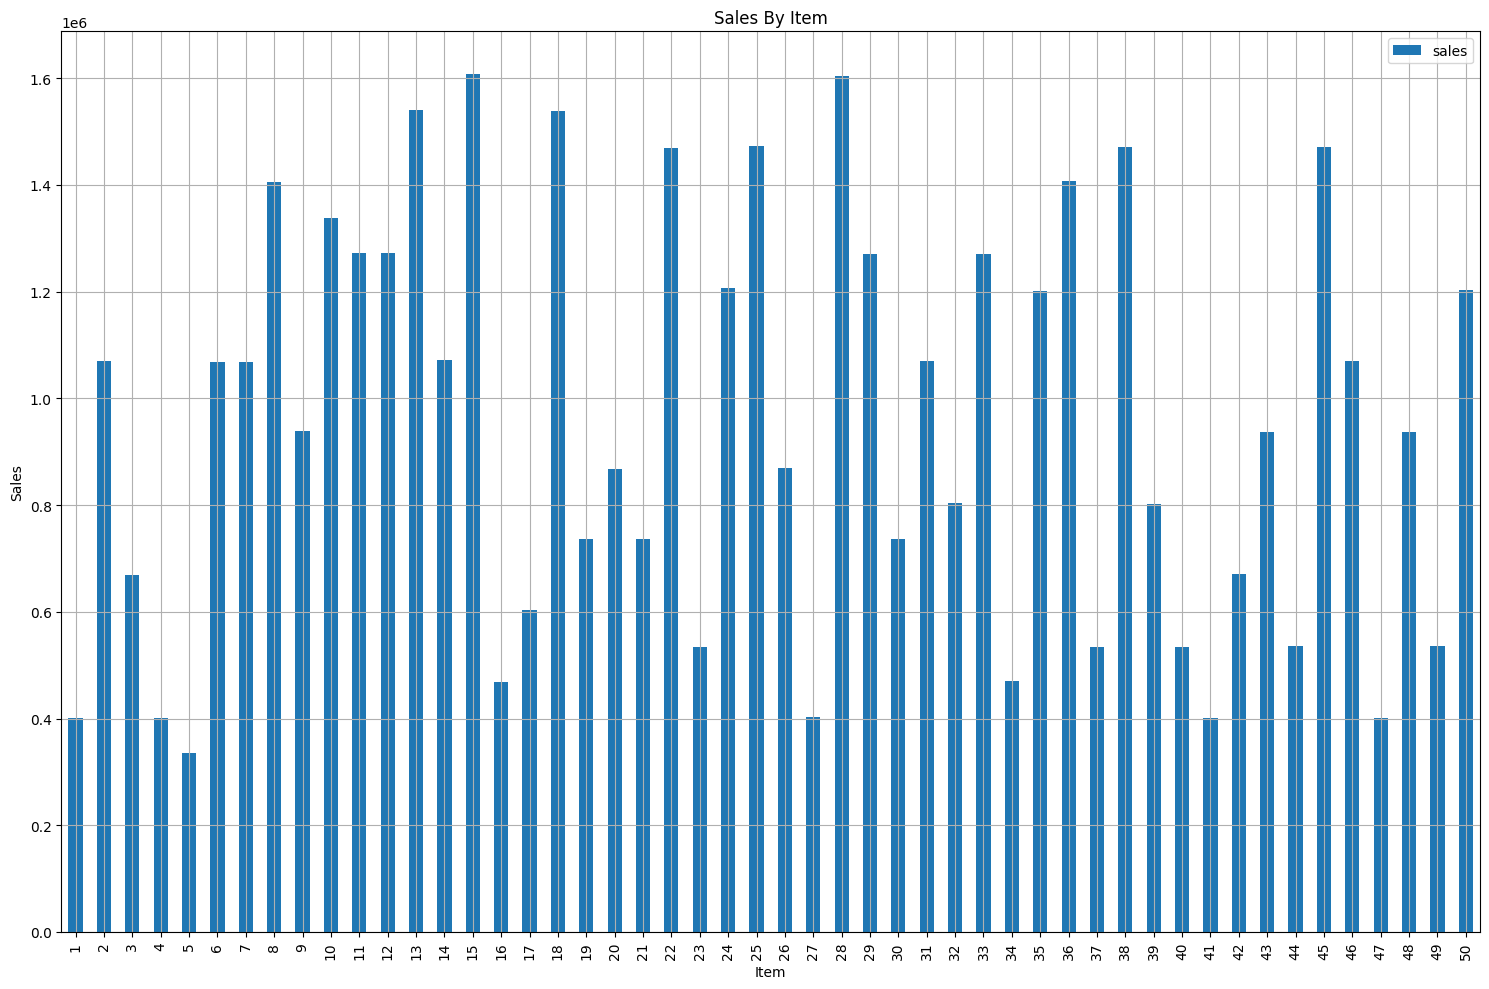

In [12]:
#Sales by item
sales_item=df.groupby('item')['sales'].sum()
sales_item.plot.bar(figsize=(15,10))
plt.title('Sales By Item')
plt.xlabel('Item')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.grid()
plt.savefig('visualizations/Sales by Item.png')
plt.show()

In [13]:
import datetime as dt

In [14]:
#Monthly,weekly,yearly trends
df['day']=df['date'].dt.day_name()
df['week']=df['date'].dt.isocalendar().week
df['month']=df['date'].dt.month
df['quarter']=df['date'].dt.quarter
df['year']=df['date'].dt.year
df['dayofweek']=df['date'].dt.day_of_week
df['is_weekend']=df['dayofweek'].isin([5,6])

In [15]:
df

,date,store,item,sales,day,week,month,quarter,year,dayofweek,is_weekend
0,2013-01-01,1,1,13,Tuesday,1,1,1,2013,1,False
1,2013-01-01,7,12,26,Tuesday,1,1,1,2013,1,False
2,2013-01-01,7,46,27,Tuesday,1,1,1,2013,1,False
3,2013-01-01,8,12,54,Tuesday,1,1,1,2013,1,False
4,2013-01-01,9,12,35,Tuesday,1,1,1,2013,1,False
...,...,...,...,...,...,...,...,...,...,...,...
912995,2017-12-31,9,34,21,Sunday,52,12,4,2017,6,True
912996,2017-12-31,10,34,32,Sunday,52,12,4,2017,6,True
912997,2017-12-31,1,35,55,Sunday,52,12,4,2017,6,True
912998,2017-12-31,8,33,100,Sunday,52,12,4,2017,6,True


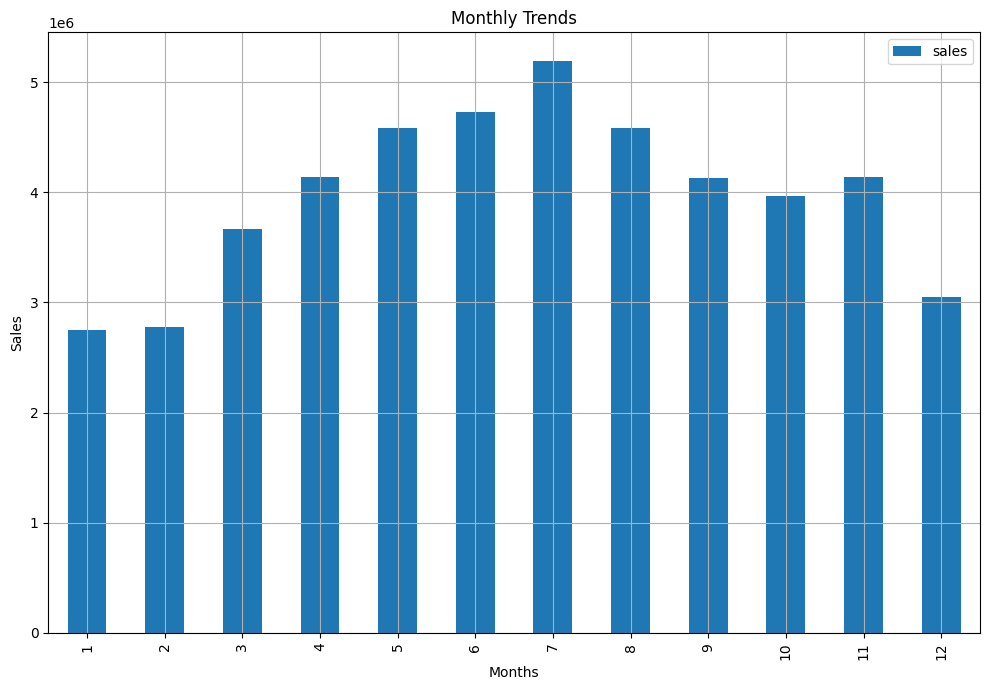

In [16]:
#monthy trends
monthly_trends=df.groupby('month')['sales'].sum()
monthly_trends.plot.bar(figsize=(10,7))
plt.title('Monthly Trends')
plt.xlabel('Months')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.grid()
plt.savefig('visualizations/Monthly Trends.png')
plt.show()

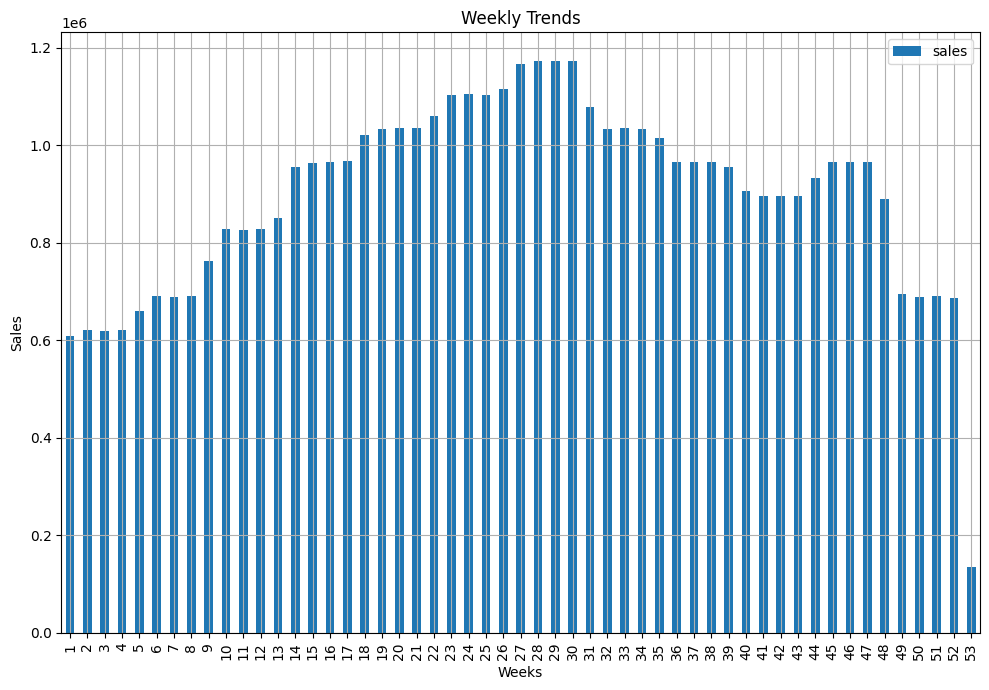

In [17]:
#weekly trends
weekly_trends=df.groupby('week')['sales'].sum()
weekly_trends.plot.bar(figsize=(10,7))
plt.title('Weekly Trends')
plt.xlabel('Weeks')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.grid()
plt.savefig('visualizations/Weekly Trends.png')
plt.show()

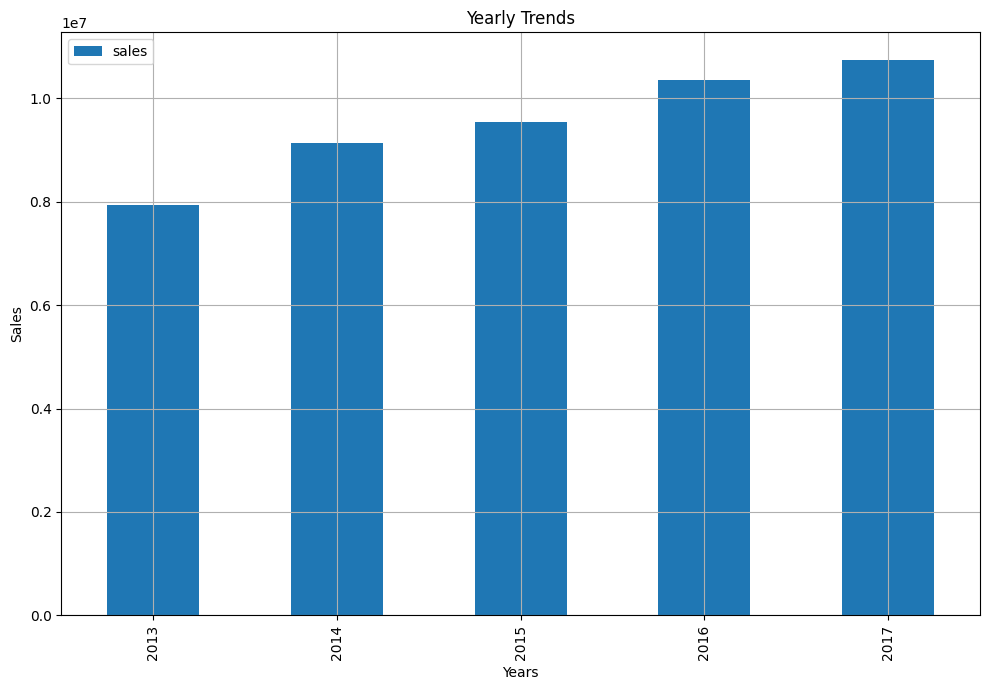

In [18]:
#yearly trends
yearly_trends=df.groupby('year')['sales'].sum()
yearly_trends.plot.bar(figsize=(10,7))
plt.title('Yearly Trends')
plt.xlabel('Years')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.grid()
plt.savefig('visualizations/Yearly Trends.png')
plt.show()

In [19]:
df.set_index('date',inplace=True)

In [20]:
for lag in [1,7,14,30]:
    df[f'lag_{lag}']=df['sales'].shift(lag)

In [21]:
lags=df[['lag_1','lag_7','lag_14','lag_30']]

C:\Users\tg_mu\AppData\Local\Temp\ipykernel_11132\467285580.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


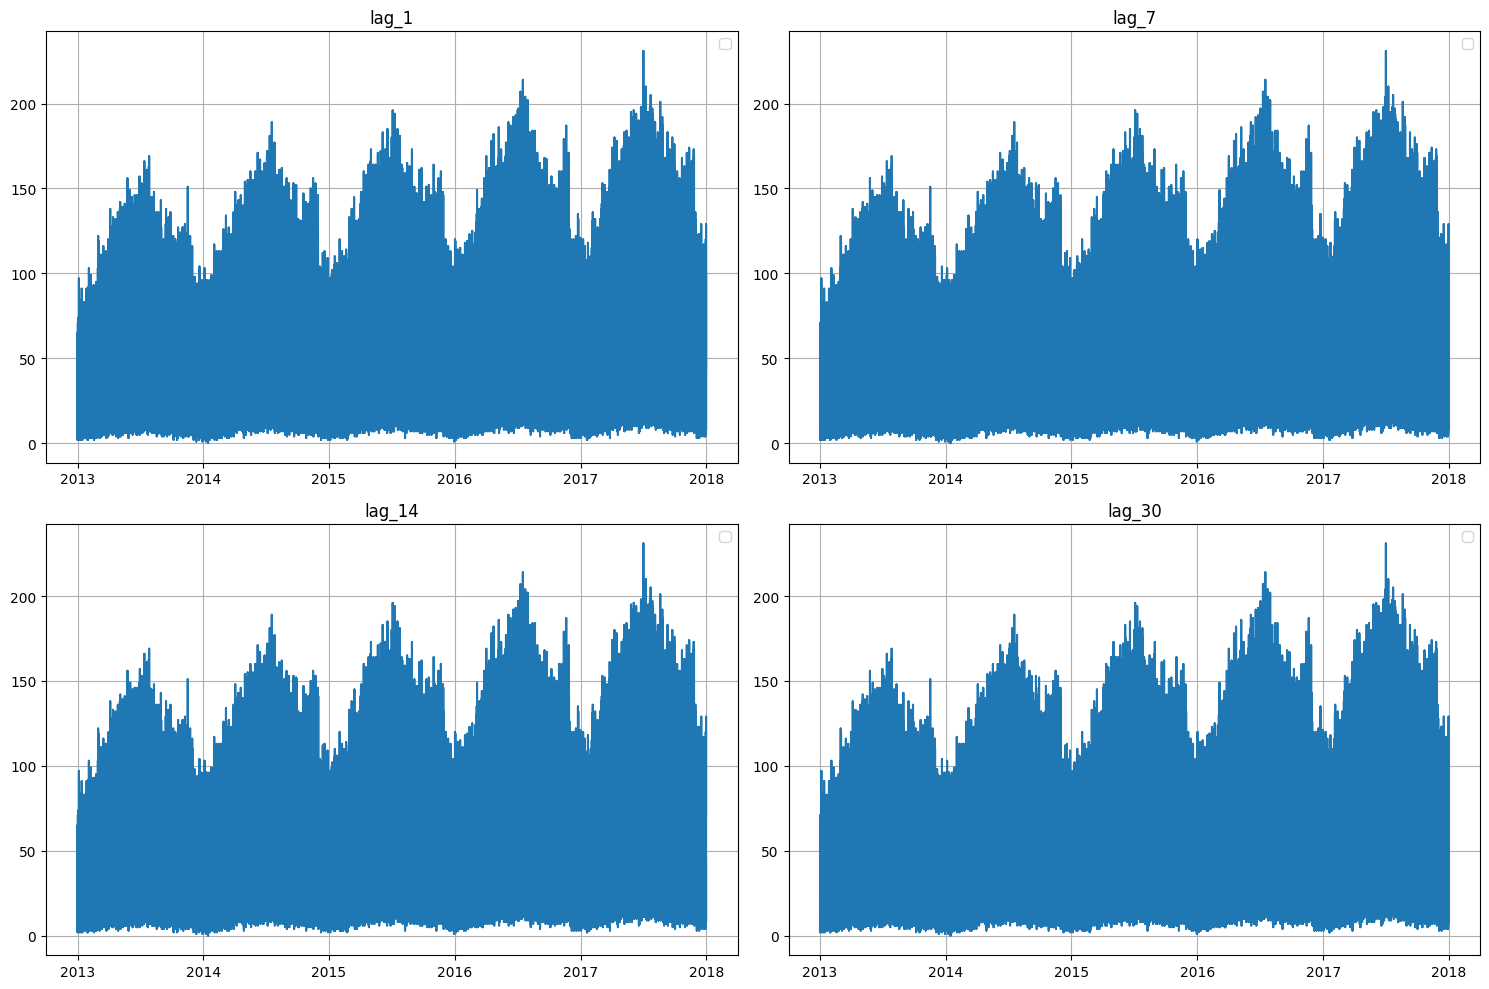

In [22]:
plt.figure(figsize=(15,10))
for index,col in enumerate(lags):
    plt.subplot(2,2,index+1)
    plt.plot(df[col])
    plt.title(col)
    plt.grid()
    plt.legend()
    plt.tight_layout()
plt.show()

In [23]:
df['rolling_mean_7']=df['sales'].shift(1).rolling(window=7).mean()
df['rolling_mean_30']=df['sales'].shift(1).rolling(window=30).mean()
df['rolling_std_7']=df['sales'].shift(1).rolling(window=7).std()

In [24]:
df['expanding_mean']=df['sales'].shift(1).expanding().mean()

In [25]:
rolling_mean=df[['rolling_mean_7','rolling_mean_30','rolling_std_7','expanding_mean']]

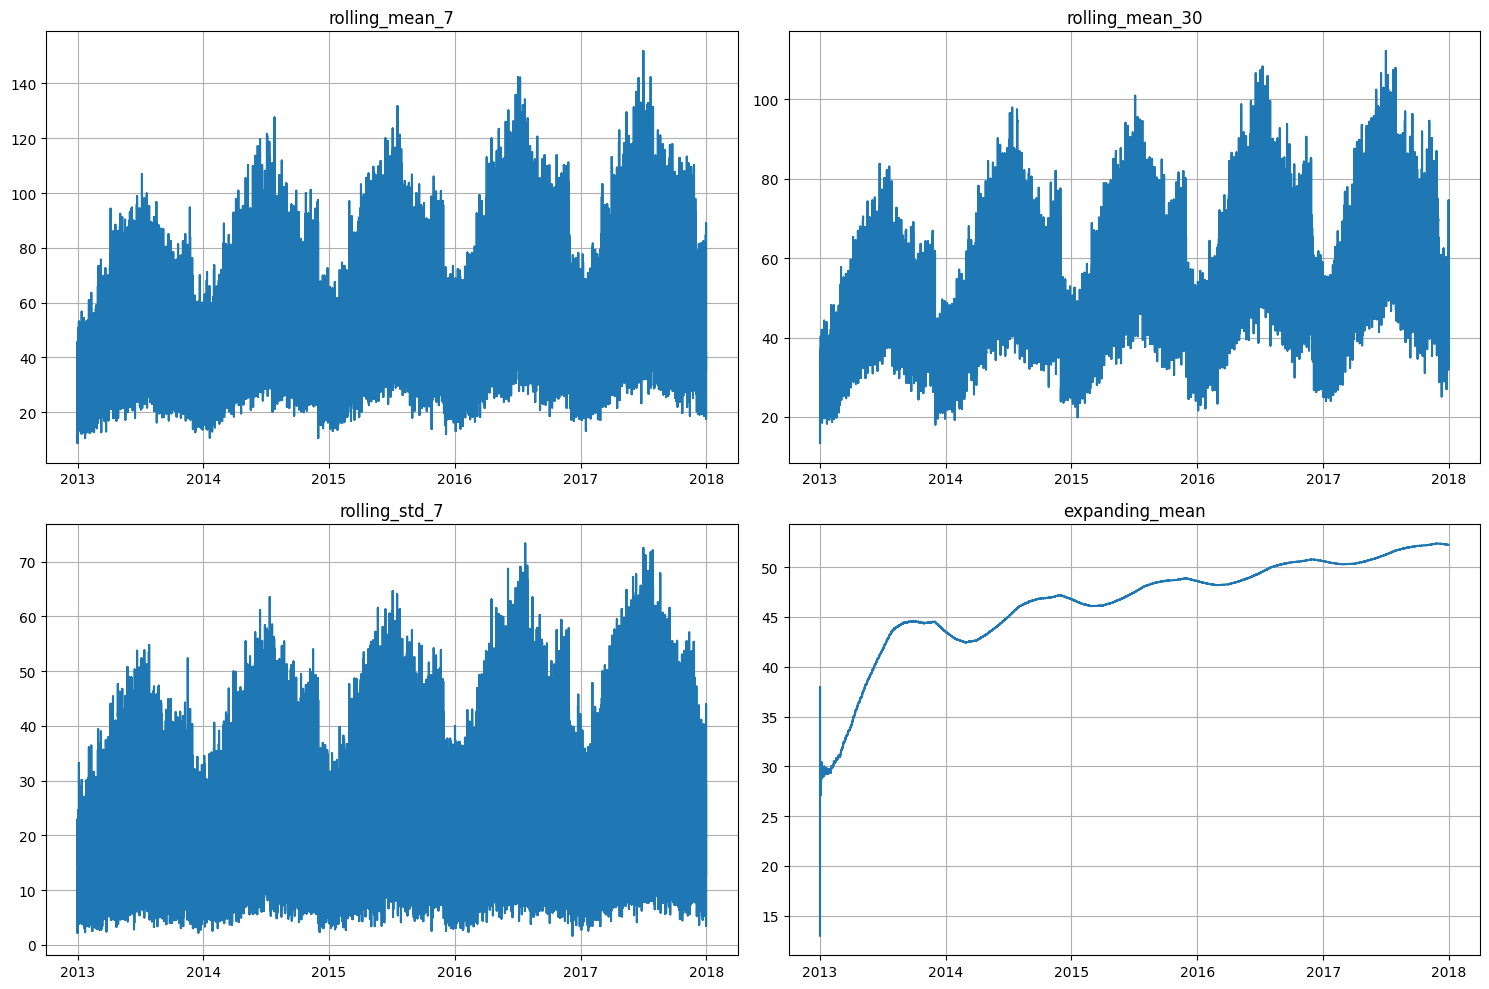

In [26]:
plt.figure(figsize=(15,10))
for index,col in enumerate(rolling_mean):
    plt.subplot(2,2,index+1)
    plt.plot(df[col])
    plt.title(col)
    plt.grid()
    plt.tight_layout()
plt.show()

In [27]:
df['prediction']=(df['lag_1']+df['rolling_mean_7'])/2

In [28]:
df['month_sin']=np.sin(2*np.pi*df['month']/12)
df['month_cos']=np.cos(2*np.pi*df['month']/12)

In [29]:
df.drop(columns=['month'],inplace=True)

In [30]:
df.dropna(inplace=True)

In [31]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error,r2_score

In [32]:
print(f'MAE:',mean_absolute_error(df['sales'],df['prediction']))
print(f'RMSE:',root_mean_squared_error(df['sales'],df['prediction']))
print(f'MAPE:',mean_absolute_percentage_error(df['sales'],df['prediction']))
print(f'r2_score:',r2_score(df['sales'],df['prediction']))

MAE: 23.799766147847127
RMSE: 30.070115017529822
MAPE: 124732174590.09802
r2_score: -0.09004215530636239


In [33]:
print((df['sales']==0).sum())

1


In [34]:
df.reset_index(inplace=True)

## Machine Learning Train/Test Split

For the machine-learning forecasting models, the dataset is divided into:

- **Training observations:** 100,000
- **Testing observations:** 182,500

The same train/test split is used for:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

This allows these three machine-learning models to be evaluated on the same test observations.

```text
Full Dataset
     ↓
Chronological / Defined Split
     ↓
┌──────────────────────┬──────────────────────┐
│   Training Dataset   │    Testing Dataset   │
│                      │                      │
│    100,000 rows      │    182,500 rows      │
└──────────────────────┴──────────────────────┘
          ↓                     ↓
       Training              Evaluation
          ↓                     ↓
 Linear Regression       MAE / RMSE / R²
 Random Forest
 Gradient Boosting

In [35]:
train=df[df['date'] < '2017-01-01']
test=df[df['date'] >= '2017-01-01']

In [36]:
df_small=train.sample(n=100000,random_state=42)

In [37]:
df_small.shape

(100000, 21)

In [38]:
X_train=df_small.drop(columns=['date','day','sales','prediction'])
y_train=df_small['sales']

X_test=test.drop(columns=['date','day','sales','prediction'])
y_test=test['sales']


In [39]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(100000, 17)
(100000,)
(182500, 17)
(182500,)


In [40]:
#Linear Regression
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()

In [41]:
lr_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_pred_lr=lr_model.predict(X_test)

In [43]:
y_pred_lr

array([50.80953535, 48.85368517, 47.72759808, ..., 56.2539382 ,
       56.20248453, 55.25936622], shape=(182500,))

In [44]:
print(f'MAE:',mean_absolute_error(y_test,y_pred_lr))
print(f'RMSE:',root_mean_squared_error(y_test,y_pred_lr))
print(f'r2_score:',r2_score(y_test,y_pred_lr))

MAE: 23.64963361295269
RMSE: 28.92615049682904
r2_score: 0.15955233103154165


In [45]:
corr = df_small.corr(numeric_only=True)['sales'].sort_values(ascending=False)
print(corr)

sales              1.000000
rolling_mean_30    0.405545
rolling_mean_7     0.346984
rolling_std_7      0.286976
prediction         0.279502
dayofweek          0.222587
lag_1              0.195207
expanding_mean     0.191885
lag_7              0.190554
lag_30             0.188256
lag_14             0.188061
is_weekend         0.177837
year               0.165407
quarter            0.094694
week               0.087635
store             -0.009215
item              -0.055132
month_sin         -0.145908
month_cos         -0.267898
Name: sales, dtype: float64


In [46]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor()

In [47]:
rf_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
y_pred_rf=rf_model.predict(X_test)

In [49]:
print(f'MAE:',mean_absolute_error(y_test,y_pred_rf))
print(f'RMSE:',root_mean_squared_error(y_test,y_pred_rf))
print(f'r2_score:',r2_score(y_test,y_pred_rf))

MAE: 7.488050520547945
RMSE: 9.948259402790292
r2_score: 0.9005914826961207


In [50]:
importance = pd.Series(rf_model.feature_importances_,index=X_train.columns).sort_values(ascending=False)

print(importance)

item               0.573758
rolling_mean_30    0.188601
store              0.149020
rolling_std_7      0.010540
expanding_mean     0.009782
rolling_mean_7     0.009442
lag_14             0.009078
lag_30             0.008975
lag_7              0.008686
lag_1              0.008480
week               0.006639
dayofweek          0.006624
month_cos          0.004348
month_sin          0.002548
year               0.001918
is_weekend         0.000856
quarter            0.000702
dtype: float64


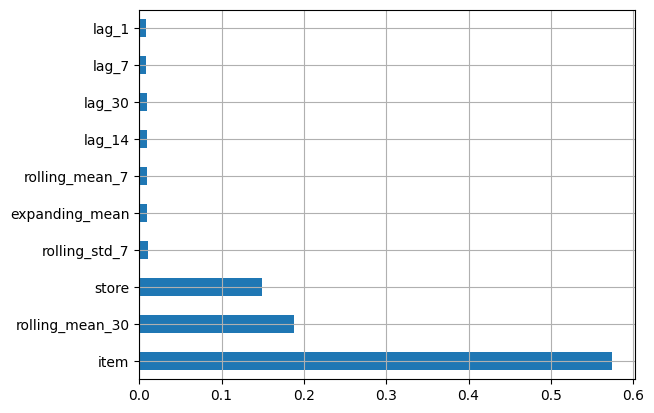

In [51]:
importance.head(10).plot(kind='barh')
plt.grid()
plt.show()

In [52]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
gr_model=GradientBoostingRegressor(n_estimators=300,
                                   learning_rate=0.05,
                                   max_depth=4,
                                   subsample=0.8,
                                   random_state=42)

In [53]:
gr_model.fit(X_train,y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,300
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [54]:
y_pred_gr=gr_model.predict(X_test)

In [55]:
print(f'MAE:',mean_absolute_error(y_test,y_pred_gr))
print(f'RMSE:',root_mean_squared_error(y_test,y_pred_gr))
print(f'r2_score:',r2_score(y_test,y_pred_gr))

MAE: 9.120452645252218
RMSE: 12.228737574085924
r2_score: 0.8497921449044974


In [56]:
importance = pd.Series(gr_model.feature_importances_,index=X_train.columns).sort_values(ascending=False)

print(importance)

item               0.618127
rolling_mean_30    0.191389
store              0.155422
month_cos          0.011480
dayofweek          0.009836
expanding_mean     0.006267
month_sin          0.002800
year               0.001518
week               0.001400
is_weekend         0.001029
rolling_mean_7     0.000260
lag_14             0.000180
rolling_std_7      0.000138
lag_1              0.000055
lag_30             0.000046
quarter            0.000035
lag_7              0.000017
dtype: float64


In [57]:
# Evaluate the three machine-learning models
model_results = []

# Linear Regression
model_results.append({
    "Model": "Linear Regression",
    "MAE": mean_absolute_error(y_test, y_pred_lr),
    "RMSE":root_mean_squared_error(y_test, y_pred_lr),
    "R²": r2_score(y_test, y_pred_lr)
})

# Random Forest
model_results.append({
    "Model": "Random Forest",
    "MAE": mean_absolute_error(y_test, y_pred_rf),
    "RMSE":root_mean_squared_error(y_test, y_pred_rf),
    "R²": r2_score(y_test, y_pred_rf)
})

# Gradient Boosting
model_results.append({
    "Model": "Gradient Boosting",
    "MAE": mean_absolute_error(y_test, y_pred_gr),
    "RMSE":root_mean_squared_error(y_test, y_pred_gr),
    "R²": r2_score(y_test, y_pred_gr)
})

# Create DataFrame
model_results_df = pd.DataFrame(model_results)

# Sort by RMSE
model_results_df = model_results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

# Display results
model_results_df

,Model,MAE,RMSE,R²
0,Random Forest,7.488051,9.948259,0.900591
1,Gradient Boosting,9.120453,12.228738,0.849792
2,Linear Regression,23.649634,28.926150,0.159552


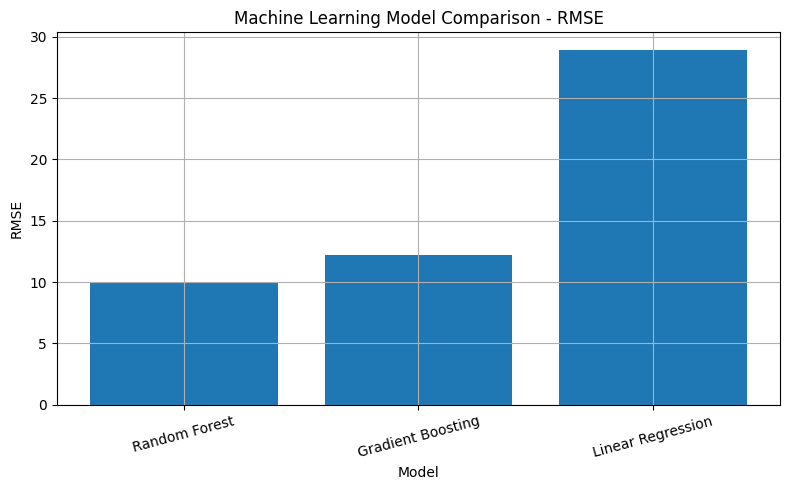

In [58]:
models = model_results_df["Model"]
rmse = model_results_df["RMSE"]

plt.figure(figsize=(8, 5))
plt.bar(models, rmse)

plt.title("Machine Learning Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.grid()
plt.savefig('visualizations/Machine Learning Model Comparison - RMSE.png')
plt.show()

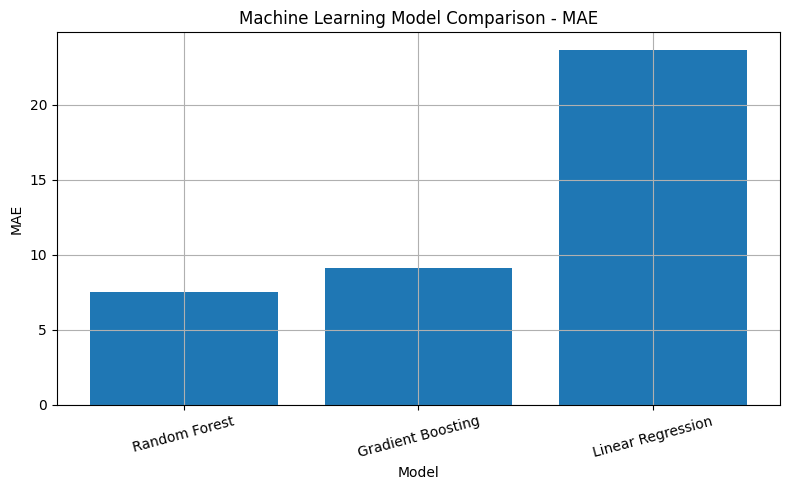

In [59]:
models = model_results_df["Model"]
mae = model_results_df["MAE"]

plt.figure(figsize=(8, 5))
plt.bar(models, mae)

plt.title("Machine Learning Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.grid()
plt.savefig('visualizations/Machine Learning Model Comparison - MAE.png')
plt.show()

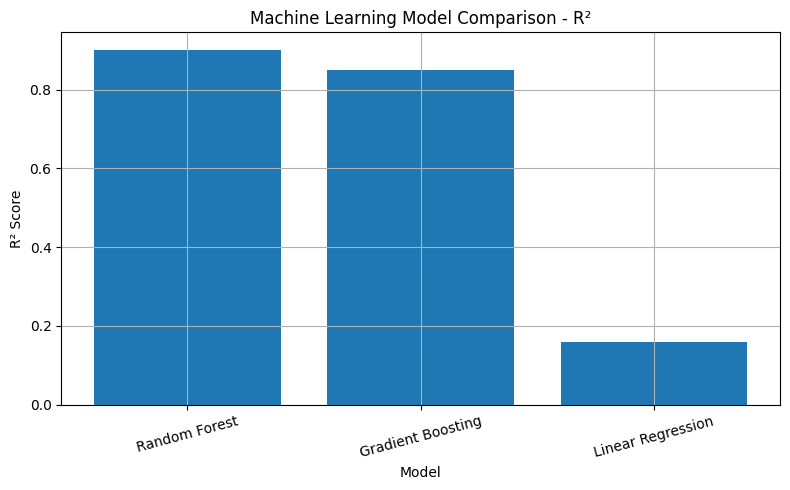

In [60]:
models = model_results_df["Model"]
r2 = model_results_df["R²"]

plt.figure(figsize=(8, 5))
plt.bar(models, r2)

plt.title("Machine Learning Model Comparison - R²")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.grid()
plt.savefig('visualizations/Machine Learning Model Comparison - R².png')
plt.show()

## Machine Learning Model Performance

Three machine-learning regression models were evaluated using the same test dataset.

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| **Random Forest** | **7.4897** | **9.9512** | **0.9005** |
| Gradient Boosting | 9.1205 | 12.2287 | 0.8498 |
| Linear Regression | 23.6496 | 28.9262 | 0.1596 |

### Best Machine Learning Model

**Random Forest Regressor** achieved the best performance among the three machine-learning models.

It produced the lowest MAE and RMSE and the highest R² score.

**R² = 0.9005**

In [61]:
df

,date,store,item,sales,day,week,quarter,year,dayofweek,is_weekend,...,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,expanding_mean,prediction,month_sin,month_cos
0,2013-01-01,5,12,22,Tuesday,1,1,2013,1,False,...,37.0,56.0,13.0,33.428571,36.200000,8.462804,36.200000,30.714286,5.000000e-01,0.866025
1,2013-01-01,4,12,36,Tuesday,1,1,2013,1,False,...,30.0,33.0,26.0,31.285714,36.500000,9.268482,35.741935,26.642857,5.000000e-01,0.866025
2,2013-01-01,4,10,30,Tuesday,1,1,2013,1,False,...,43.0,47.0,27.0,32.142857,36.833333,9.406178,35.750000,34.071429,5.000000e-01,0.866025
3,2013-01-01,5,10,31,Tuesday,1,1,2013,1,False,...,22.0,46.0,54.0,30.285714,36.933333,8.097619,35.575758,30.142857,5.000000e-01,0.866025
4,2013-01-01,6,10,29,Tuesday,1,1,2013,1,False,...,45.0,43.0,35.0,31.571429,36.166667,7.230886,35.441176,31.285714,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912965,2017-12-31,9,34,21,Sunday,52,4,2017,6,True,...,29.0,53.0,120.0,27.857143,52.466667,9.822229,52.250255,35.428571,-2.449294e-16,1.000000
912966,2017-12-31,10,34,32,Sunday,52,4,2017,6,True,...,36.0,49.0,45.0,26.714286,49.166667,10.127755,52.250221,23.857143,-2.449294e-16,1.000000
912967,2017-12-31,1,35,55,Sunday,52,4,2017,6,True,...,31.0,70.0,61.0,26.142857,48.733333,9.616454,52.250199,29.071429,-2.449294e-16,1.000000
912968,2017-12-31,8,33,100,Sunday,52,4,2017,6,True,...,16.0,58.0,84.0,29.571429,48.533333,14.615712,52.250202,42.285714,-2.449294e-16,1.000000


In [62]:
df_single = df[(df['store'] == 1) & (df['item'] == 1)]

In [63]:
df_single=df_single[['date','sales']]
df_single

,date,sales
669,2013-01-02,11
1032,2013-01-03,14
1831,2013-01-04,13
2261,2013-01-05,10
2629,2013-01-06,12
...,...,...
910725,2017-12-27,14
911166,2017-12-28,19
911678,2017-12-29,15
912311,2017-12-30,27


In [64]:
df_single.set_index('date',inplace=True)

In [65]:
df_single

,sales
date,
2013-01-02,11
2013-01-03,14
2013-01-04,13
2013-01-05,10
2013-01-06,12
...,...
2017-12-27,14
2017-12-28,19
2017-12-29,15


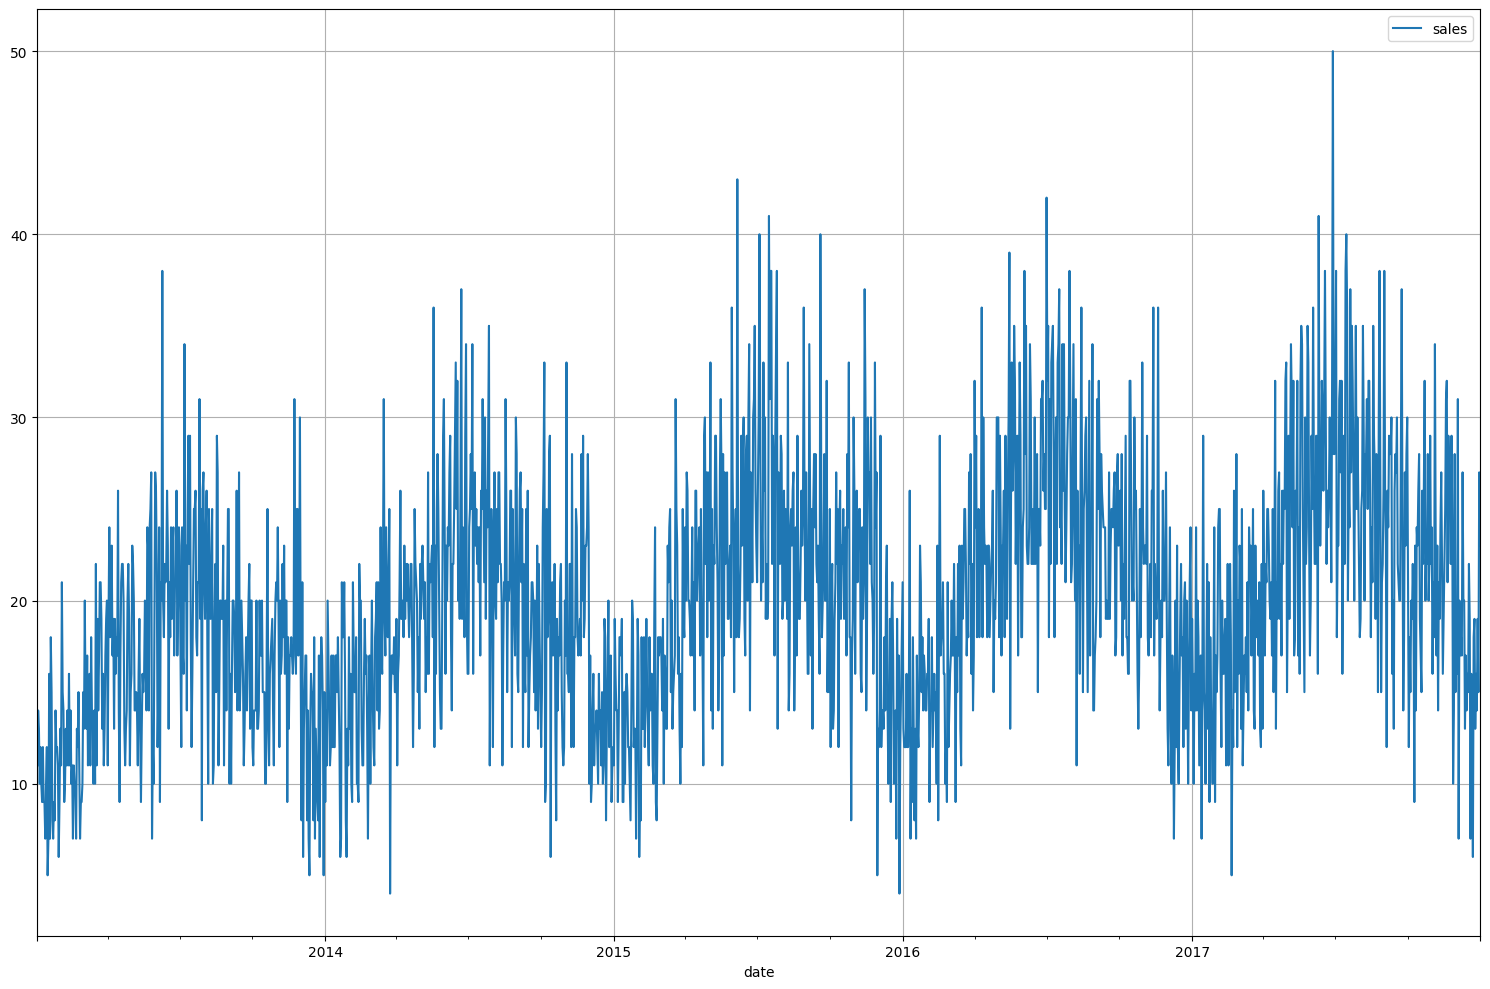

In [66]:
df_single.plot(figsize=(15,10))
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
from statsmodels.tsa.seasonal import seasonal_decompose

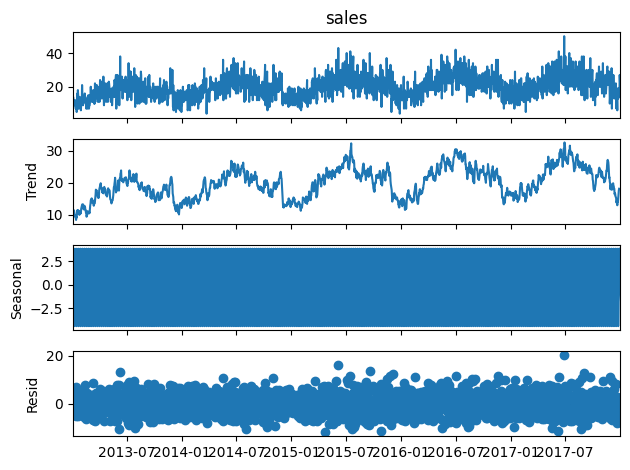

In [68]:
decomposition = seasonal_decompose(df_single['sales'])
decomposition.plot()
plt.show()

In [69]:
from statsmodels.tsa.stattools import adfuller

#ADF Test - if the p-value < 0.05 - Data is stationary
result = adfuller(df_single)

print(f'ADF Statistic,{result[0]}') #some default value based upon the critial values
print(f'p-value={result[1]}')

if(result[1]>0.05):
    print("The series is not stationary")
else:
    print("series is stationary")

ADF Statistic,-3.1141745837880404
p-value=0.025521834731766942
series is stationary


In [70]:
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

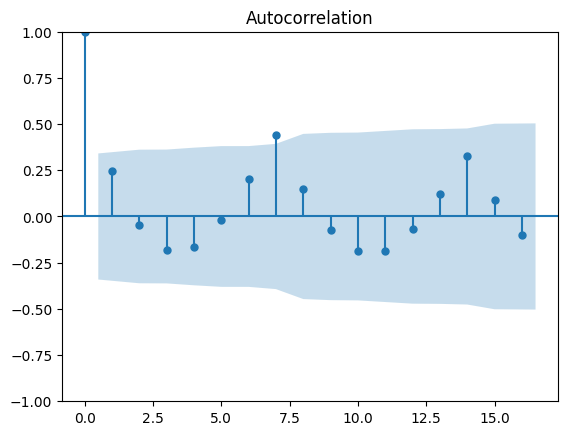

In [71]:
acf_plot=acf(df_single.dropna())
plot_acf(acf_plot)
plt.show()

In [72]:
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf

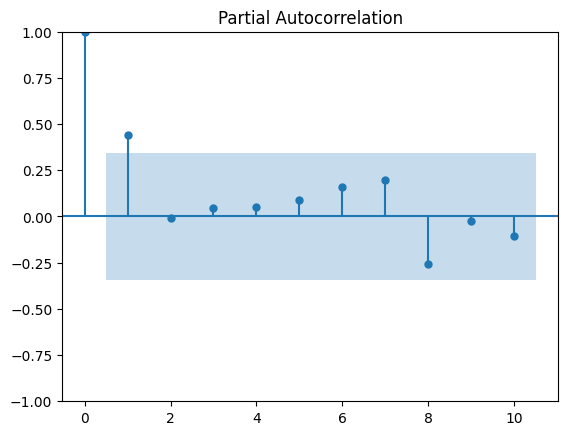

In [73]:
pacf_plot=pacf(df_single)
plot_pacf(pacf_plot, lags=10)
plt.show()

In [74]:
train_ts = df_single.loc[:'2016-12-31']
test_ts = df_single.loc['2017-01-01':]

In [75]:
train_ts

,sales
date,
2013-01-02,11
2013-01-03,14
2013-01-04,13
2013-01-05,10
2013-01-06,12
...,...
2016-12-27,10
2016-12-28,16
2016-12-29,21


In [76]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train_ts,
    seasonal=True,
    m=7,
    stepwise=True,
    trace=True,
    suppress_warnings=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.65 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=9788.351, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=9366.024, Time=0.15 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=8921.625, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=9786.351, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=9007.698, Time=0.09 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=0.98 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=8872.633, Time=0.60 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=2.02 sec
 ARIMA(0,1,0)(0,0,2)[7] intercept   : AIC=9675.915, Time=0.27 sec
 ARIMA(1,1,1)(0,0,2)[7] intercept   : AIC=8867.295, Time=0.66 sec
 ARIMA(1,1,1)(0,0,1)[7] intercept   : AIC=8916.123, Time=0.32 sec
 ARIMA(1,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=2.12 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=8664.678, Time=1.18 sec
 ARIMA(1,1,1)(1,0,0)[7] intercept   : AIC=8877.028, T

In [77]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [78]:
model=SARIMAX(train_ts,order=(1,0,1),seasonal_order=(1,0,1,7))
model=model.fit()

C:\Users\tg_mu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\tg_mu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<Axes: xlabel='date'>

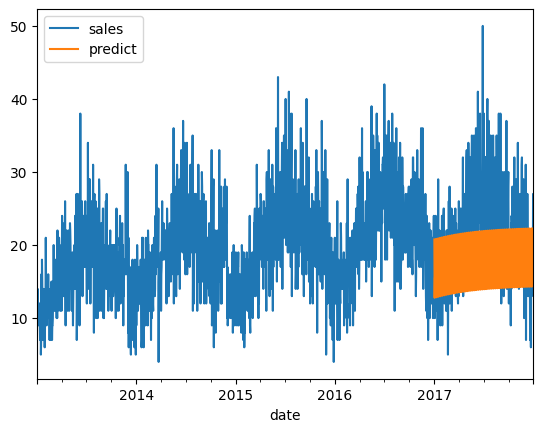

In [79]:
df_single['predict']=model.predict(start=len(train_ts),end=len(train_ts)+len(test_ts)-1, dynamic=True)
df_single[['sales','predict']].plot()

In [80]:
df_single

,sales,predict
date,,
2013-01-02,11,NaN
2013-01-03,14,NaN
2013-01-04,13,NaN
2013-01-05,10,NaN
2013-01-06,12,NaN
...,...,...
2017-12-27,14,17.400008
2017-12-28,19,17.786612
2017-12-29,15,19.734840


In [81]:
test_ts

,sales
date,
2017-01-01,19
2017-01-02,15
2017-01-03,10
2017-01-04,16
2017-01-05,14
...,...
2017-12-27,14
2017-12-28,19
2017-12-29,15


In [82]:
pred_ts = model.forecast(steps=len(test_ts))

print("MAE :", mean_absolute_error(test_ts, pred_ts))
print("RMSE:", root_mean_squared_error(test_ts, pred_ts))
print("R²  :", r2_score(test_ts, pred_ts))

MAE : 5.869141233854568
RMSE: 7.402631561062918
R²  : -0.13653944118741812


In [83]:
sarimax_mae = mean_absolute_error(test_ts, pred_ts)
sarimax_rmse = root_mean_squared_error(test_ts, pred_ts)
sarimax_r2 = r2_score(test_ts, pred_ts)

print("SARIMAX MAE :", sarimax_mae)
print("SARIMAX RMSE:", sarimax_rmse)
print("SARIMAX R²  :", sarimax_r2)

SARIMAX MAE : 5.869141233854568
SARIMAX RMSE: 7.402631561062918
SARIMAX R²  : -0.13653944118741812


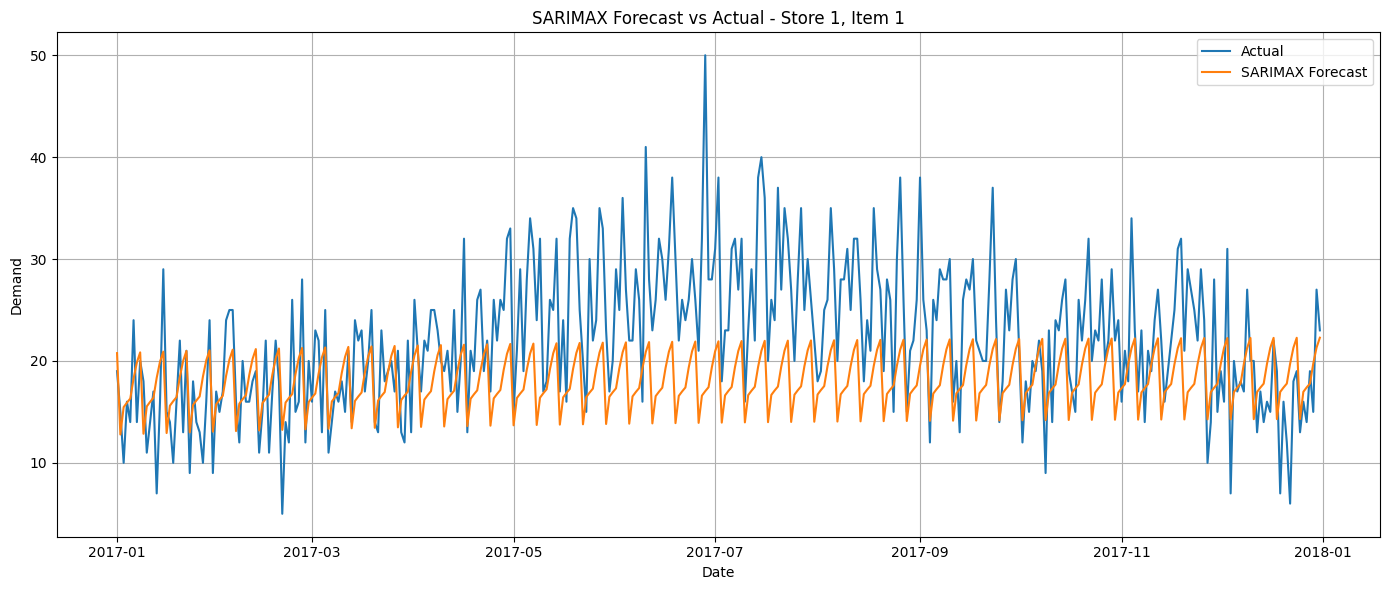

In [84]:
plt.figure(figsize=(14, 6))

plt.plot(test_ts.index, test_ts.values, label="Actual")
plt.plot(test_ts.index, pred_ts.values, label="SARIMAX Forecast")

plt.title("SARIMAX Forecast vs Actual - Store 1, Item 1")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.tight_layout()
plt.grid()
plt.savefig('visualizations/SARIMAX Forecast vs Actual - Store 1, Item 1.png')
plt.show()

In [85]:
# SARIMAX residuals
sarimax_residuals = test_ts.values - pred_ts.values

print("Mean residual:", sarimax_residuals.mean())
print("Std residual :", sarimax_residuals.std())

Mean residual: 4.117552499770733
Std residual : 7.411496026737733


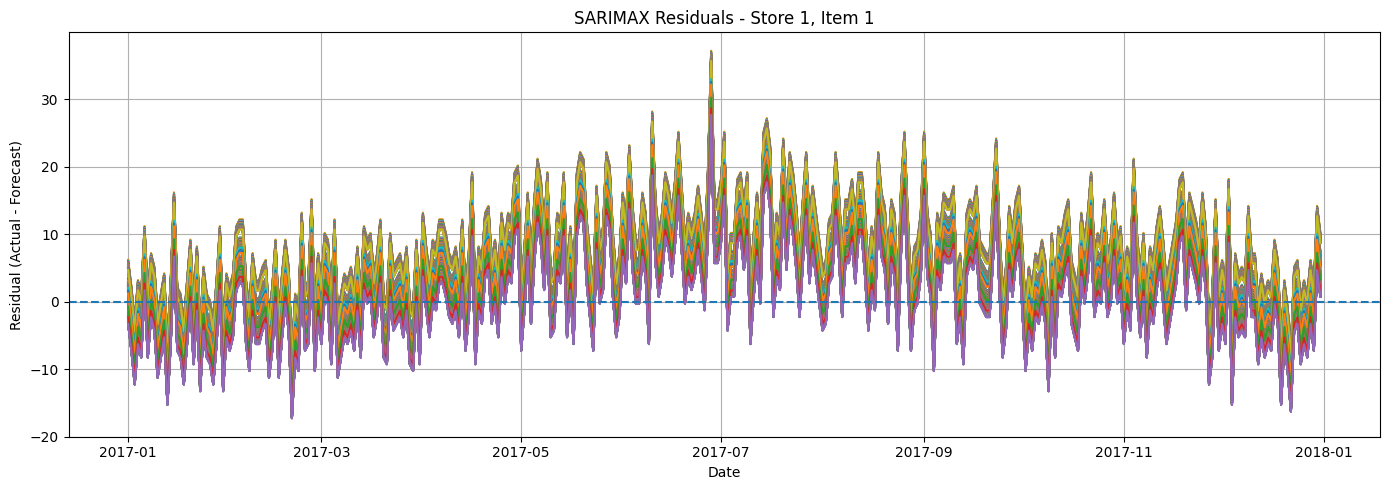

In [86]:
plt.figure(figsize=(14, 5))

plt.plot(test_ts.index, sarimax_residuals)

plt.axhline(0, linestyle="--")

plt.title("SARIMAX Residuals - Store 1, Item 1")
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Forecast)")
plt.tight_layout()
plt.grid()
plt.savefig('visualizations/SARIMAX Residuals - Store 1, Item 1.png')
plt.show()

In [87]:
final_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "Linear Regression",
        "SARIMAX",
        "LSTM"
    ],
    "Scope": [
        "ML dataset",
        "ML dataset",
        "ML dataset",
        "Store 1 + Item 1",
        "Separate LSTM notebook"
    ],
    "Test Size": [
        182500,
        182500,
        182500,
        365,
        None
    ],
    "MAE": [
        7.489669,
        9.120453,
        23.649634,
        5.869141,
        21.548021
    ],
    "RMSE": [
        9.951221,
        12.228738,
        28.926150,
        7.402632,
        26.086544
    ],
    "R²": [
        0.900532,
        0.849792,
        0.159552,
        -0.136539,
        0.056834
    ]
})

final_results

,Model,Scope,Test Size,MAE,RMSE,R²
0,Random Forest,ML dataset,182500.0,7.489669,9.951221,0.900532
1,Gradient Boosting,ML dataset,182500.0,9.120453,12.228738,0.849792
2,Linear Regression,ML dataset,182500.0,23.649634,28.926150,0.159552
3,SARIMAX,Store 1 + Item 1,365.0,5.869141,7.402632,-0.136539
4,LSTM,Separate LSTM notebook,NaN,21.548021,26.086544,0.056834


## Overall Model Performance Comparison

The forecasting project evaluated multiple approaches, including machine-learning regression models and statistical time-series forecasting.

| Model | Evaluation Set | MAE | RMSE | R² |
|---|---|---:|---:|---:|
| **SARIMAX** | 365-step time-series test | **5.8691** | **7.4026** | -0.1365 |
| **Random Forest** | ML test set (182,500 observations) | 7.4897 | 9.9512 | **0.9005** |
| **Gradient Boosting** | ML test set (182,500 observations) | 9.1205 | 12.2287 | 0.8498 |
| Linear Regression | ML test set (182,500 observations) | 23.6496 | 28.9262 | 0.1596 |
| LSTM | LSTM test set | 21.5480 | 26.0865 | 0.0568 |

### Interpretation

SARIMAX achieved the lowest MAE and RMSE among the evaluated models. However, its negative R² indicates that the model does not explain the variation in the SARIMAX evaluation period well according to the R² metric.

Random Forest achieved the highest R² among the models and performed strongly on the machine-learning test set.

Because the models were evaluated using different forecasting setups and test periods, the metrics should not be interpreted as a perfectly controlled head-to-head comparison.

The results demonstrate the importance of evaluating multiple forecasting approaches using appropriate out-of-sample data.